In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:

# Load all datasets
def load_and_prepare_data():
    """Load all CSV files and prepare combined dataset"""

    # Load individual datasets
    bam_svnn = pd.read_csv('bam_svnn_grid_results.csv')
    bam_svnn['model'] = 'BAM-SVNN'

    no_bam_svnn = pd.read_csv('no_bam_svnn_grid_results.csv')
    no_bam_svnn['model'] = 'No-BAM-SVNN'

    naive = pd.read_csv('naive_grid_results.csv')
    naive['model'] = 'Naive'

    pca = pd.read_csv('pca_grid_results.csv')
    pca['model'] = 'PCA'
    pca['gso_type'] = 'N/A'  # PCA doesn't use GSO
    pca['sparsify'] = 'N/A'

    rand = pd.read_csv('rand_grid_results.csv')
    rand['model'] = 'Random'

    # Combine all datasets
    all_data = pd.concat([bam_svnn, no_bam_svnn, naive, pca, rand], ignore_index=True)

    # Create combined identifier for detailed analysis
    all_data['config'] = all_data['model'] + '_' + all_data['gso_type'].astype(str) + '_' + all_data['sparsify'].astype(str)
    all_data['config'] = all_data['config'].str.replace('_N/A_N/A', '')

    return all_data, bam_svnn, no_bam_svnn, naive, pca, rand

# Load data
all_data, bam_svnn, no_bam_svnn, naive, pca, rand = load_and_prepare_data()

print("Data loaded successfully!")
print(f"Total experiments: {len(all_data)}")
print(f"Models: {all_data['model'].unique()}")
print(f"Seeds: {all_data['seed'].unique()}")

Data loaded successfully!
Total experiments: 125
Models: ['BAM-SVNN' 'No-BAM-SVNN' 'Naive' 'PCA' 'Random']
Seeds: [   10    16    42  2025 12345]


In [3]:

# ============================================================================
# 1. COMPREHENSIVE SUMMARY TABLE
# ============================================================================

In [4]:

def create_summary_table(data):
    """Create comprehensive summary statistics table"""

    # Group by model and calculate statistics
    summary = data.groupby('model').agg({
        'rmse': ['mean', 'std', 'min', 'max'],
        'mean_diversity': ['mean', 'std', 'min', 'max'],
        'mean_novelty': ['mean', 'std', 'min', 'max'],
        'elapsed_sec': ['mean', 'std']
    }).round(4)

    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns]

    return summary

def create_detailed_summary_table(data):
    """Create detailed summary by model configuration"""

    # Filter only SVNN models for detailed analysis
    svnn_data = data[data['model'].isin(['BAM-SVNN', 'No-BAM-SVNN'])].copy()

    # Create configuration identifier
    svnn_data['full_config'] = (svnn_data['model'] + ' (' +
                               svnn_data['gso_type'] + ', ' +
                               svnn_data['sparsify'] + ')')

    detailed_summary = svnn_data.groupby('full_config').agg({
        'rmse': ['mean', 'std'],
        'mean_diversity': ['mean', 'std'],
        'mean_novelty': ['mean', 'std'],
        'elapsed_sec': ['mean', 'std']
    }).round(4)

    detailed_summary.columns = ['_'.join(col).strip() for col in detailed_summary.columns]

    return detailed_summary

# Create and display summary tables
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY TABLE - BY MODEL")
print("="*80)
summary_table = create_summary_table(all_data)
print(summary_table)

print("\n" + "="*80)
print("DETAILED SUMMARY TABLE - SVNN CONFIGURATIONS")
print("="*80)
detailed_table = create_detailed_summary_table(all_data)
print(detailed_table)


COMPREHENSIVE SUMMARY TABLE - BY MODEL
             rmse_mean  rmse_std  rmse_min  rmse_max  mean_diversity_mean  \
model                                                                       
BAM-SVNN        0.9631    0.0094    0.9503    0.9757               0.8464   
Naive           1.0258    0.0293    1.0053    1.1103               0.8627   
No-BAM-SVNN     0.9632    0.0094    0.9500    0.9751               0.8652   
PCA             0.9309    0.0023    0.9273    0.9332               0.8697   
Random          1.2164    0.0108    1.2036    1.2344               0.8665   

             mean_diversity_std  mean_diversity_min  mean_diversity_max  \
model                                                                     
BAM-SVNN                 0.0078              0.8269              0.8600   
Naive                    0.0068              0.8497              0.8756   
No-BAM-SVNN              0.0069              0.8522              0.8760   
PCA                      0.0010              

In [5]:

# ============================================================================
# 2. PERFORMANCE COMPARISON BAR CHARTS
# ============================================================================

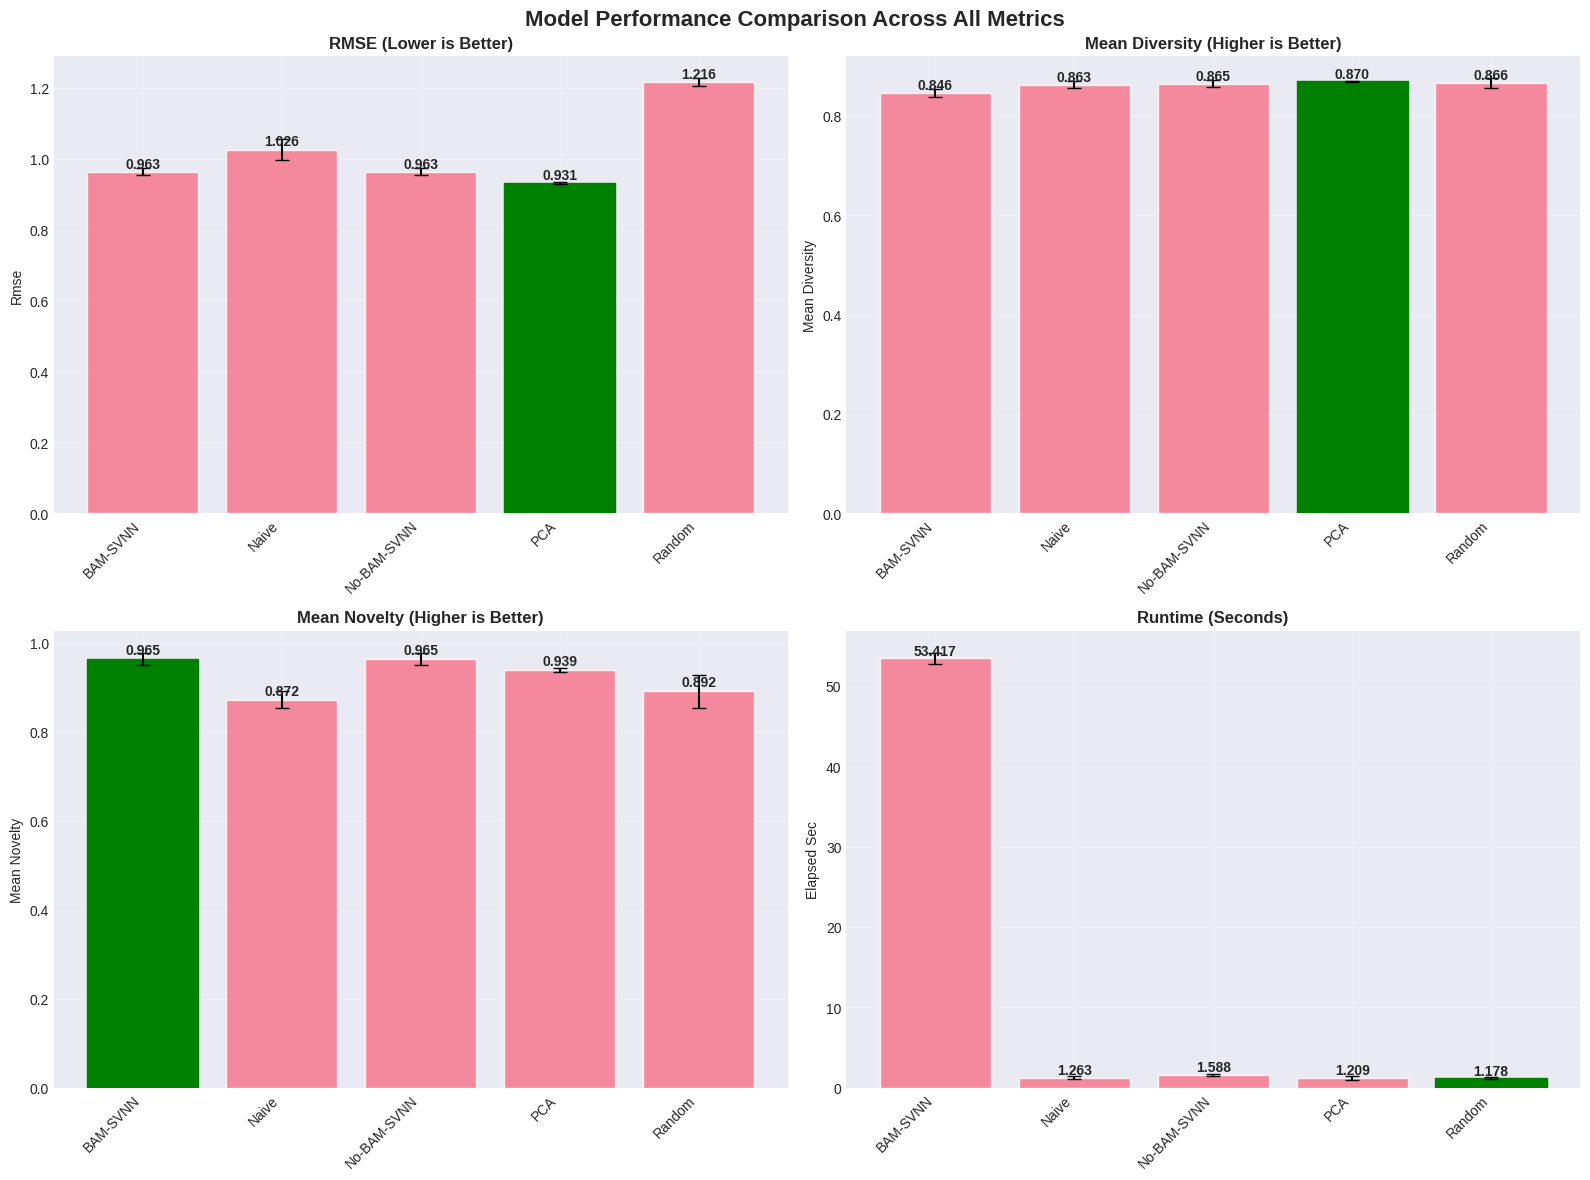

In [6]:

def plot_performance_metrics(data):
    """Create comprehensive bar charts for all metrics"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Comparison Across All Metrics', fontsize=16, fontweight='bold')

    metrics = ['rmse', 'mean_diversity', 'mean_novelty', 'elapsed_sec']
    titles = ['RMSE (Lower is Better)', 'Mean Diversity (Higher is Better)',
              'Mean Novelty (Higher is Better)', 'Runtime (Seconds)']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx//2, idx%2]

        # Calculate mean and std for each model
        summary_stats = data.groupby('model')[metric].agg(['mean', 'std']).reset_index()

        # Create bar plot with error bars
        bars = ax.bar(summary_stats['model'], summary_stats['mean'],
                     yerr=summary_stats['std'], capsize=5, alpha=0.8)

        # Color bars based on performance
        if metric == 'rmse' or metric == 'elapsed_sec':
            # Lower is better - color best performer green
            best_idx = summary_stats['mean'].idxmin()
        else:
            # Higher is better - color best performer green
            best_idx = summary_stats['mean'].idxmax()

        bars[best_idx].set_color('green')
        bars[best_idx].set_alpha(1.0)

        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(metric.replace('_', ' ').title())
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        ax.grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, mean_val in zip(bars, summary_stats['mean']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + summary_stats['std'].max()*0.1,
                   f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_performance_metrics(all_data)

In [7]:

# ============================================================================
# 3. SVNN DETAILED COMPARISON (GSO TYPE & SPARSIFICATION)
# ============================================================================

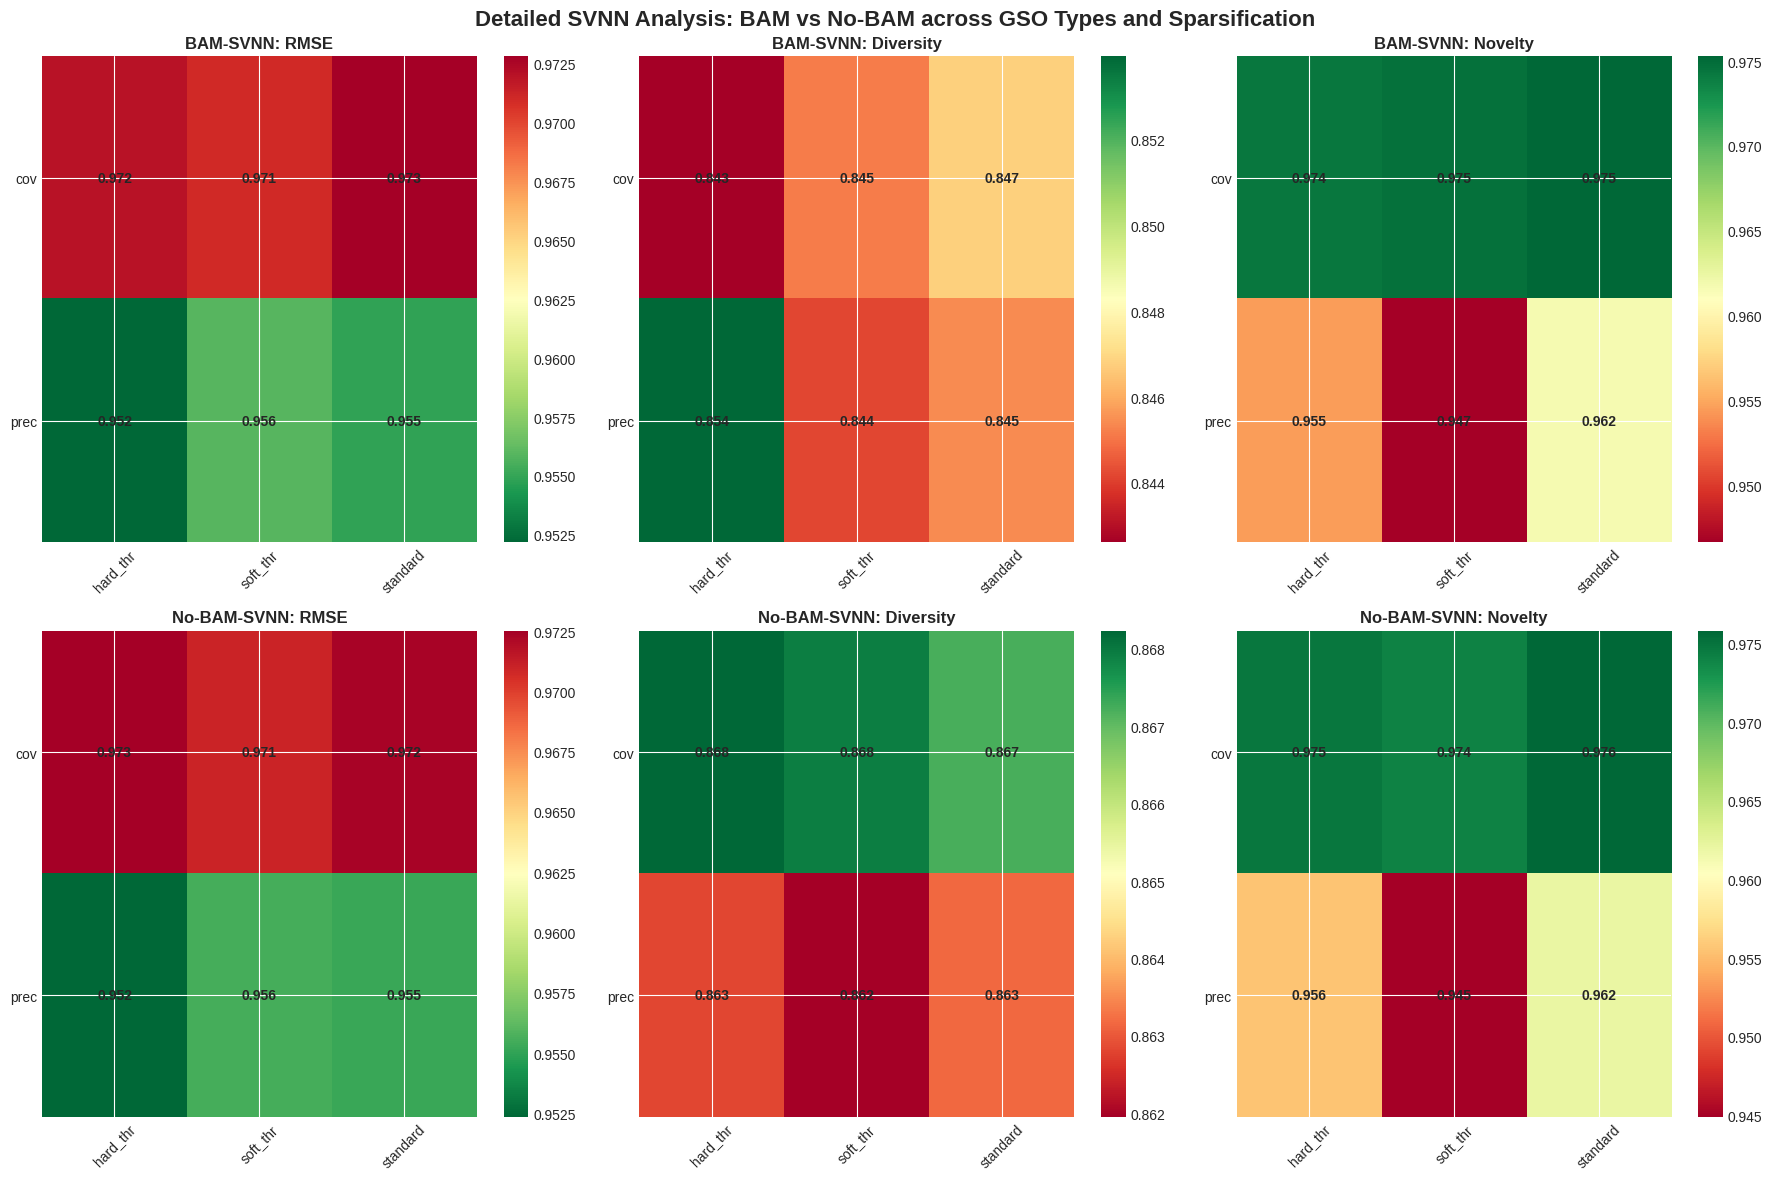

In [8]:

def plot_svnn_detailed_analysis(bam_data, no_bam_data):
    """Detailed analysis of SVNN variants"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Detailed SVNN Analysis: BAM vs No-BAM across GSO Types and Sparsification',
                 fontsize=16, fontweight='bold')

    metrics = ['rmse', 'mean_diversity', 'mean_novelty']
    metric_names = ['RMSE', 'Diversity', 'Novelty']

    for col, (metric, name) in enumerate(zip(metrics, metric_names)):
        # BAM results
        ax1 = axes[0, col]
        bam_pivot = bam_data.groupby(['gso_type', 'sparsify'])[metric].mean().unstack()
        im1 = ax1.imshow(bam_pivot.values, cmap='RdYlGn_r' if metric == 'rmse' else 'RdYlGn',
                        aspect='auto', interpolation='nearest')
        ax1.set_title(f'BAM-SVNN: {name}', fontweight='bold')
        ax1.set_xticks(range(len(bam_pivot.columns)))
        ax1.set_xticklabels(bam_pivot.columns, rotation=45)
        ax1.set_yticks(range(len(bam_pivot.index)))
        ax1.set_yticklabels(bam_pivot.index)

        # Add text annotations
        for i in range(len(bam_pivot.index)):
            for j in range(len(bam_pivot.columns)):
                ax1.text(j, i, f'{bam_pivot.iloc[i, j]:.3f}',
                        ha='center', va='center', fontweight='bold')

        plt.colorbar(im1, ax=ax1)

        # No-BAM results
        ax2 = axes[1, col]
        no_bam_pivot = no_bam_data.groupby(['gso_type', 'sparsify'])[metric].mean().unstack()
        im2 = ax2.imshow(no_bam_pivot.values, cmap='RdYlGn_r' if metric == 'rmse' else 'RdYlGn',
                        aspect='auto', interpolation='nearest')
        ax2.set_title(f'No-BAM-SVNN: {name}', fontweight='bold')
        ax2.set_xticks(range(len(no_bam_pivot.columns)))
        ax2.set_xticklabels(no_bam_pivot.columns, rotation=45)
        ax2.set_yticks(range(len(no_bam_pivot.index)))
        ax2.set_yticklabels(no_bam_pivot.index)

        # Add text annotations
        for i in range(len(no_bam_pivot.index)):
            for j in range(len(no_bam_pivot.columns)):
                ax2.text(j, i, f'{no_bam_pivot.iloc[i, j]:.3f}',
                        ha='center', va='center', fontweight='bold')

        plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_svnn_detailed_analysis(bam_svnn, no_bam_svnn)

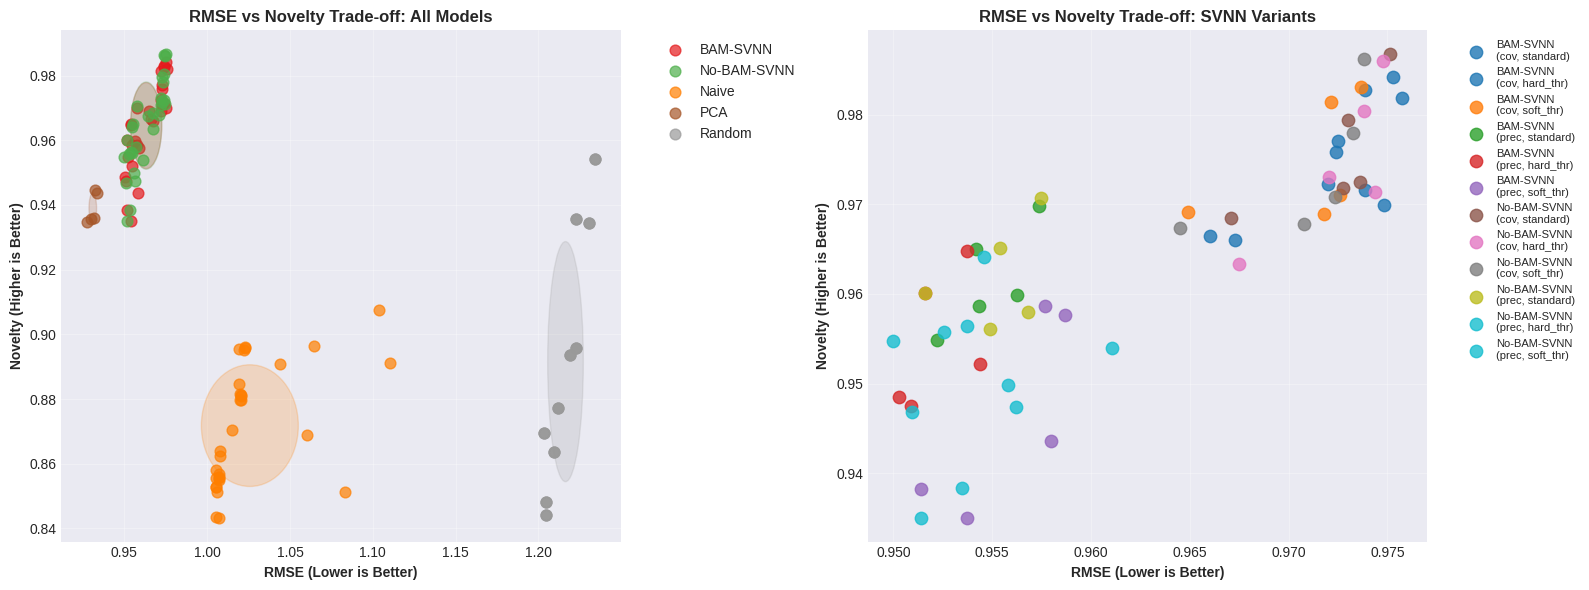

In [9]:

# ============================================================================
# 4. PARETO FRONTIER ANALYSIS (RMSE vs NOVELTY)
# ============================================================================

def plot_pareto_analysis(data):
    """Create Pareto frontier plot showing RMSE vs Novelty trade-off"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left plot: All models
    models = data['model'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(models)))

    for model, color in zip(models, colors):
        model_data = data[data['model'] == model]
        ax1.scatter(model_data['rmse'], model_data['mean_novelty'],
                   label=model, alpha=0.7, s=60, color=color)

        # Add confidence ellipse
        if len(model_data) > 2:
            from matplotlib.patches import Ellipse
            mean_x, mean_y = model_data['rmse'].mean(), model_data['mean_novelty'].mean()
            std_x, std_y = model_data['rmse'].std(), model_data['mean_novelty'].std()
            ellipse = Ellipse((mean_x, mean_y), 2*std_x, 2*std_y,
                            alpha=0.2, color=color)
            ax1.add_patch(ellipse)

    ax1.set_xlabel('RMSE (Lower is Better)', fontweight='bold')
    ax1.set_ylabel('Novelty (Higher is Better)', fontweight='bold')
    ax1.set_title('RMSE vs Novelty Trade-off: All Models', fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Right plot: SVNN variants only
    svnn_data = data[data['model'].isin(['BAM-SVNN', 'No-BAM-SVNN'])]

    # Create unique combinations
    svnn_data['config_label'] = (svnn_data['model'] + '\n(' +
                                svnn_data['gso_type'] + ', ' +
                                svnn_data['sparsify'] + ')')

    configs = svnn_data['config_label'].unique()
    colors_svnn = plt.cm.tab10(np.linspace(0, 1, len(configs)))

    for config, color in zip(configs, colors_svnn):
        config_data = svnn_data[svnn_data['config_label'] == config]
        ax2.scatter(config_data['rmse'], config_data['mean_novelty'],
                   label=config, alpha=0.8, s=80, color=color)

    ax2.set_xlabel('RMSE (Lower is Better)', fontweight='bold')
    ax2.set_ylabel('Novelty (Higher is Better)', fontweight='bold')
    ax2.set_title('RMSE vs Novelty Trade-off: SVNN Variants', fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_pareto_analysis(all_data)

In [10]:

# ============================================================================
# 5. STATISTICAL ANALYSIS (ANOVA)
# ============================================================================

def perform_statistical_analysis(data):
    """Perform ANOVA and post-hoc tests"""

    print("\n" + "="*80)
    print("STATISTICAL ANALYSIS - ONE-WAY ANOVA")
    print("="*80)

    metrics = ['rmse', 'mean_diversity', 'mean_novelty']

    for metric in metrics:
        print(f"\n{metric.upper()} Analysis:")
        print("-" * 40)

        # Group data by model
        groups = [data[data['model'] == model][metric].values
                 for model in data['model'].unique()]

        # Perform ANOVA
        f_stat, p_value = f_oneway(*groups)
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value: {p_value:.6f}")

        if p_value < 0.05:
            print("Result: Significant difference between models (p < 0.05)")

            # Post-hoc Tukey test
            tukey_results = pairwise_tukeyhsd(data[metric], data['model'])
            print("\nTukey Post-hoc Test Results:")
            print(tukey_results)
        else:
            print("Result: No significant difference between models (p >= 0.05)")

perform_statistical_analysis(all_data)


STATISTICAL ANALYSIS - ONE-WAY ANOVA

RMSE Analysis:
----------------------------------------
F-statistic: 1214.9633
p-value: 0.000000
Result: Significant difference between models (p < 0.05)

Tukey Post-hoc Test Results:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj  lower   upper  reject
-------------------------------------------------------------
   BAM-SVNN       Naive   0.0626   0.0  0.0507  0.0746   True
   BAM-SVNN No-BAM-SVNN      0.0   1.0 -0.0119   0.012  False
   BAM-SVNN         PCA  -0.0322 0.001 -0.0545 -0.0099   True
   BAM-SVNN      Random   0.2533   0.0  0.2413  0.2652   True
      Naive No-BAM-SVNN  -0.0626   0.0 -0.0745 -0.0507   True
      Naive         PCA  -0.0949   0.0 -0.1172 -0.0725   True
      Naive      Random   0.1906   0.0  0.1787  0.2026   True
No-BAM-SVNN         PCA  -0.0323 0.001 -0.0546 -0.0099   True
No-BAM-SVNN      Random   0.2532   0.0  0.2413  0.2652   True
        PCA      Random   0.2855 

In [16]:

# ============================================================================
# 6. CORRELATION ANALYSIS
# ============================================================================

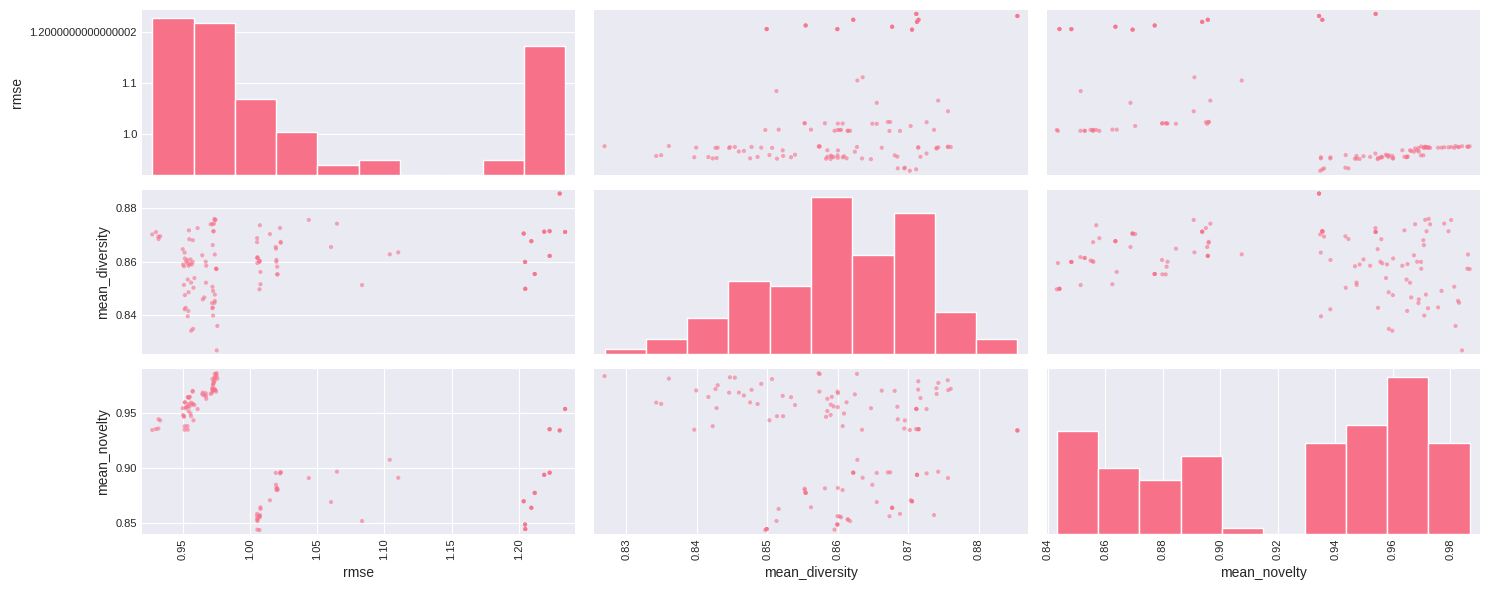

In [17]:

def plot_correlation_analysis(data):
    """Analyze correlations between metrics"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Correlation heatmap
    numeric_cols = ['rmse', 'mean_diversity', 'mean_novelty', 'elapsed_sec']
    corr_matrix = data[numeric_cols].corr()

    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                square=True, ax=ax1, cbar_kws={'label': 'Correlation'})
    ax1.set_title('Correlation Matrix: All Metrics', fontweight='bold')

    # Scatter plot matrix for key metrics
    from pandas.plotting import scatter_matrix
    key_metrics = ['rmse', 'mean_diversity', 'mean_novelty']
    scatter_matrix(data[key_metrics], ax=ax2, figsize=(8, 6), alpha=0.6, diagonal='hist')
    ax2.set_title('Pairwise Relationships: Key Metrics', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_correlation_analysis(all_data)

In [18]:

# ============================================================================
# 7. EFFICIENCY ANALYSIS
# ============================================================================

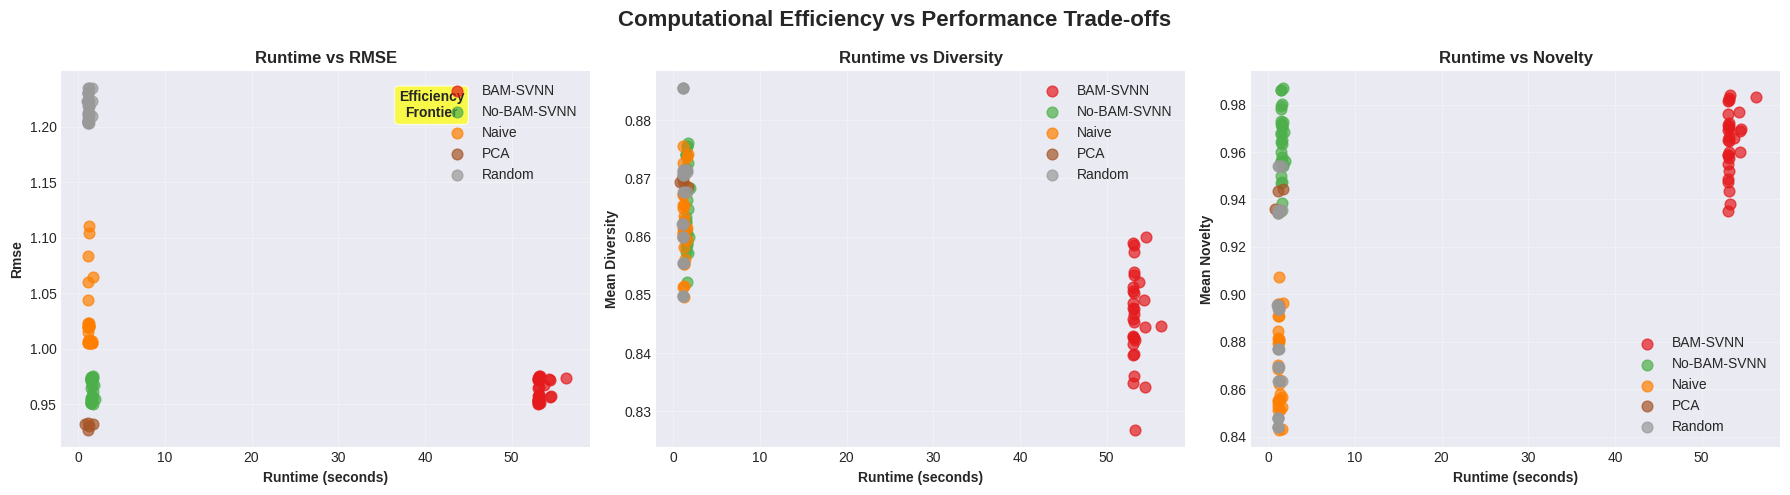

In [19]:

def plot_efficiency_analysis(data):
    """Analyze computational efficiency vs performance trade-offs"""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = ['rmse', 'mean_diversity', 'mean_novelty']
    titles = ['Runtime vs RMSE', 'Runtime vs Diversity', 'Runtime vs Novelty']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx]

        models = data['model'].unique()
        colors = plt.cm.Set1(np.linspace(0, 1, len(models)))

        for model, color in zip(models, colors):
            model_data = data[data['model'] == model]
            ax.scatter(model_data['elapsed_sec'], model_data[metric],
                      label=model, alpha=0.7, s=60, color=color)

        ax.set_xlabel('Runtime (seconds)', fontweight='bold')
        ax.set_ylabel(metric.replace('_', ' ').title(), fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Add efficiency frontier annotation
        if metric == 'rmse':
            # For RMSE, lower is better - find models with good RMSE and low runtime
            ax.text(0.7, 0.95, 'Efficiency\nFrontier', transform=ax.transAxes,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                   ha='center', va='top', fontweight='bold')

    plt.suptitle('Computational Efficiency vs Performance Trade-offs',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_efficiency_analysis(all_data)

In [20]:

# ============================================================================
# 8. ADVANCED INSIGHTS TABLE
# ============================================================================

In [21]:

def create_advanced_insights_table(data):
    """Create table with advanced performance insights"""

    print("\n" + "="*80)
    print("ADVANCED INSIGHTS TABLE")
    print("="*80)

    insights = []

    for model in data['model'].unique():
        model_data = data[data['model'] == model]

        insights.append({
            'Model': model,
            'RMSE_Mean': model_data['rmse'].mean(),
            'RMSE_Std': model_data['rmse'].std(),
            'Novelty_Mean': model_data['mean_novelty'].mean(),
            'Novelty_Std': model_data['mean_novelty'].std(),
            'Diversity_Mean': model_data['mean_diversity'].mean(),
            'Diversity_Std': model_data['mean_diversity'].std(),
            'Runtime_Mean': model_data['elapsed_sec'].mean(),
            'Efficiency_Score': (1 / model_data['rmse'].mean()) * model_data['mean_novelty'].mean() / (model_data['elapsed_sec'].mean() + 1),
            'Variability_Score': (model_data['rmse'].std() + model_data['mean_novelty'].std()) / 2,
            'N_Experiments': len(model_data)
        })

    insights_df = pd.DataFrame(insights)
    insights_df = insights_df.round(4)
    insights_df = insights_df.sort_values('Efficiency_Score', ascending=False)

    print(insights_df.to_string(index=False))

    return insights_df

advanced_insights = create_advanced_insights_table(all_data)


ADVANCED INSIGHTS TABLE
      Model  RMSE_Mean  RMSE_Std  Novelty_Mean  Novelty_Std  Diversity_Mean  Diversity_Std  Runtime_Mean  Efficiency_Score  Variability_Score  N_Experiments
        PCA     0.9309    0.0023        0.9389       0.0047          0.8697         0.0010        1.2087            0.4567             0.0035              5
No-BAM-SVNN     0.9632    0.0094        0.9645       0.0135          0.8652         0.0069        1.5885            0.3869             0.0115             30
      Naive     1.0258    0.0293        0.8718       0.0188          0.8627         0.0068        1.2631            0.3755             0.0240             30
     Random     1.2164    0.0108        0.8916       0.0371          0.8665         0.0097        1.1780            0.3365             0.0239             30
   BAM-SVNN     0.9631    0.0094        0.9645       0.0133          0.8464         0.0078       53.4174            0.0184             0.0114             30


In [22]:

# ============================================================================
# 9. MODEL RANKING VISUALIZATION
# ============================================================================

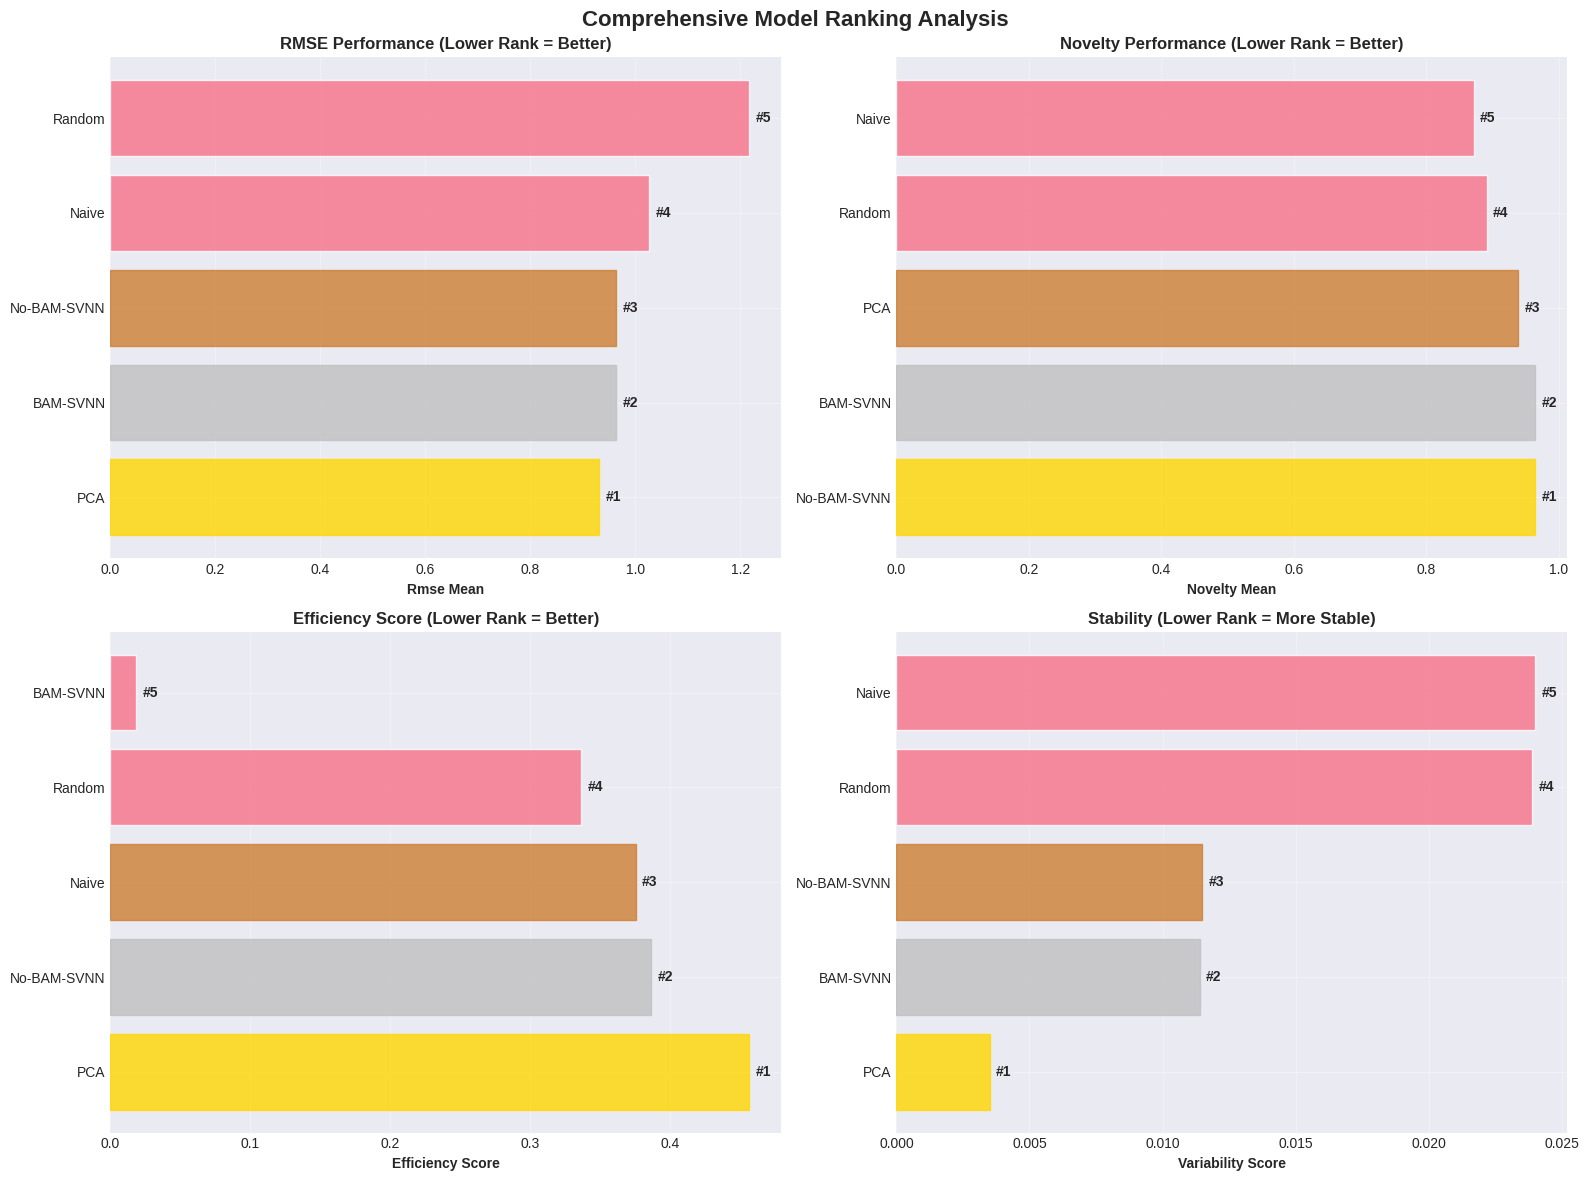

In [23]:

def plot_model_ranking(insights_df):
    """Create comprehensive model ranking visualization"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comprehensive Model Ranking Analysis', fontsize=16, fontweight='bold')

    # Ranking by different criteria
    criteria = [
        ('RMSE_Mean', 'RMSE Performance (Lower Rank = Better)', True),
        ('Novelty_Mean', 'Novelty Performance (Lower Rank = Better)', False),
        ('Efficiency_Score', 'Efficiency Score (Lower Rank = Better)', False),
        ('Variability_Score', 'Stability (Lower Rank = More Stable)', True)
    ]

    for idx, (col, title, ascending) in enumerate(criteria):
        ax = axes[idx//2, idx%2]

        # Sort and rank
        ranked_data = insights_df.sort_values(col, ascending=ascending).reset_index(drop=True)
        ranked_data['rank'] = range(1, len(ranked_data) + 1)

        # Create horizontal bar plot
        bars = ax.barh(ranked_data['Model'], ranked_data[col], alpha=0.8)

        # Color best performer
        bars[0].set_color('gold')
        bars[1].set_color('silver') if len(bars) > 1 else None
        bars[2].set_color('#CD7F32') if len(bars) > 2 else None  # Bronze

        ax.set_xlabel(col.replace('_', ' ').title(), fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Add rank annotations
        for i, (bar, rank) in enumerate(zip(bars, ranked_data['rank'])):
            ax.text(bar.get_width() + max(ranked_data[col]) * 0.01, bar.get_y() + bar.get_height()/2,
                   f'#{rank}', ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_model_ranking(advanced_insights)

In [24]:

# ============================================================================
# 10. FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================

In [25]:

def generate_final_summary(data, insights_df):
    """Generate final summary and recommendations"""

    print("\n" + "="*80)
    print("FINAL SUMMARY AND RECOMMENDATIONS")
    print("="*80)

    best_rmse = insights_df.loc[insights_df['RMSE_Mean'].idxmin(), 'Model']
    best_novelty = insights_df.loc[insights_df['Novelty_Mean'].idxmax(), 'Model']
    best_efficiency = insights_df.loc[insights_df['Efficiency_Score'].idxmax(), 'Model']
    most_stable = insights_df.loc[insights_df['Variability_Score'].idxmin(), 'Model']

    print(f"🏆 Best RMSE Performance: {best_rmse}")
    print(f"🌟 Best Novelty Performance: {best_novelty}")
    print(f"⚡ Most Efficient: {best_efficiency}")
    print(f"📊 Most Stable: {most_stable}")

    print(f"\n📈 KEY INSIGHTS:")
    print(f"1. RMSE Range: {data['rmse'].min():.4f} - {data['rmse'].max():.4f}")
    print(f"2. Novelty Range: {data['mean_novelty'].min():.4f} - {data['mean_novelty'].max():.4f}")
    print(f"3. Diversity Range: {data['mean_diversity'].min():.4f} - {data['mean_diversity'].max():.4f}")
    print(f"4. Runtime Range: {data['elapsed_sec'].min():.2f}s - {data['elapsed_sec'].max():.2f}s")

    # Check if BAM improves novelty
    if 'BAM-SVNN' in data['model'].values and 'No-BAM-SVNN' in data['model'].values:
        bam_novelty = data[data['model'] == 'BAM-SVNN']['mean_novelty'].mean()
        no_bam_novelty = data[data['model'] == 'No-BAM-SVNN']['mean_novelty'].mean()
        novelty_improvement = ((bam_novelty - no_bam_novelty) / no_bam_novelty) * 100

        bam_rmse = data[data['model'] == 'BAM-SVNN']['rmse'].mean()
        no_bam_rmse = data[data['model'] == 'No-BAM-SVNN']['rmse'].mean()
        rmse_degradation = ((bam_rmse - no_bam_rmse) / no_bam_rmse) * 100

        print(f"\n🔍 BAM IMPACT ANALYSIS:")
        print(f"   • Novelty Improvement: {novelty_improvement:+.2f}%")
        print(f"   • RMSE Degradation: {rmse_degradation:+.2f}%")
        print(f"   • Trade-off Ratio: {abs(novelty_improvement/rmse_degradation):.2f}x novelty gain per 1% RMSE loss")

generate_final_summary(all_data, advanced_insights)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("The notebook has generated comprehensive visualizations and statistical analysis.")
print("Key outputs include:")
print("• Summary tables with descriptive statistics")
print("• Performance comparison bar charts")
print("• Detailed SVNN configuration heatmaps")
print("• Pareto frontier analysis for RMSE vs Novelty trade-offs")
print("• Statistical significance testing (ANOVA + post-hoc)")
print("• Correlation analysis between metrics")
print("• Computational efficiency analysis")
print("• Advanced insights and model ranking")
print("• Final recommendations")


FINAL SUMMARY AND RECOMMENDATIONS
🏆 Best RMSE Performance: PCA
🌟 Best Novelty Performance: No-BAM-SVNN
⚡ Most Efficient: PCA
📊 Most Stable: PCA

📈 KEY INSIGHTS:
1. RMSE Range: 0.9273 - 1.2344
2. Novelty Range: 0.8431 - 0.9868
3. Diversity Range: 0.8269 - 0.8855
4. Runtime Range: 0.84s - 56.28s

🔍 BAM IMPACT ANALYSIS:
   • Novelty Improvement: +0.00%
   • RMSE Degradation: -0.00%
   • Trade-off Ratio: 0.27x novelty gain per 1% RMSE loss

ANALYSIS COMPLETE!
The notebook has generated comprehensive visualizations and statistical analysis.
Key outputs include:
• Summary tables with descriptive statistics
• Performance comparison bar charts
• Detailed SVNN configuration heatmaps
• Pareto frontier analysis for RMSE vs Novelty trade-offs
• Statistical significance testing (ANOVA + post-hoc)
• Correlation analysis between metrics
• Computational efficiency analysis
• Advanced insights and model ranking
• Final recommendations
